In [26]:
pip install pandas numpy matplotlib seaborn openpyxl jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)


In [28]:
import os

os.listdir("data")

['retail_sales_dataset.csv']

In [29]:
import pandas as pd

df = pd.read_csv("data/retail_sales_dataset.csv")

In [30]:
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [31]:

df.shape

(120000, 17)

In [32]:

df.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

In [33]:

df.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

In [34]:
df.isnull().sum()

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [35]:
import os

os.listdir("data")

['retail_sales_dataset.csv']

In [36]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

quantity: 0 negative values
unit_price: 0 negative values
discount_pct: 0 negative values
sales_amount: 0 negative values


In [37]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


transaction_id
<StringArray>
['T0000001', 'T0000002', 'T0000003', 'T0000004', 'T0000005', 'T0000006',
 'T0000007', 'T0000008', 'T0000009', 'T0000010',
 ...
 'T0119991', 'T0119992', 'T0119993', 'T0119994', 'T0119995', 'T0119996',
 'T0119997', 'T0119998', 'T0119999', 'T0120000']
Length: 120000, dtype: str

transaction_date
<StringArray>
['2024-04-24', '2025-07-12', '2025-06-01', '2025-08-26', '2024-12-10',
 '2024-02-14', '2025-10-05', '2024-10-23', '2025-01-14', '2024-09-07',
 ...
 '2025-07-24', '2025-07-31', '2025-04-23', '2025-03-14', '2025-10-24',
 '2025-01-23', '2024-09-01', '2024-04-29', '2025-05-14', '2024-03-12']
Length: 730, dtype: str

customer_id
<StringArray>
['C000820', 'C002849', 'C019727', 'C009116', 'C003350', 'C023912', 'C020268',
 'C002615', 'C011642', 'C005355',
 ...
 'C004592', 'C018924', 'C014680', 'C000531', 'C006017', 'C021404', 'C023961',
 'C009075', 'C023725', 'C006904']
Length: 24784, dtype: str

customer_gender
<StringArray>
['Other', 'Male', 'Female']
Length: 

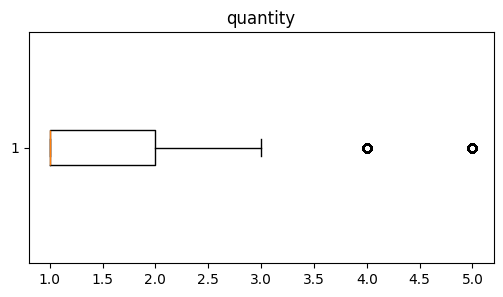

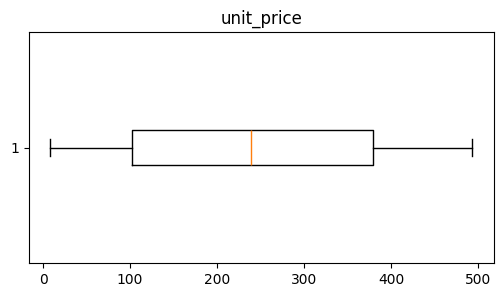

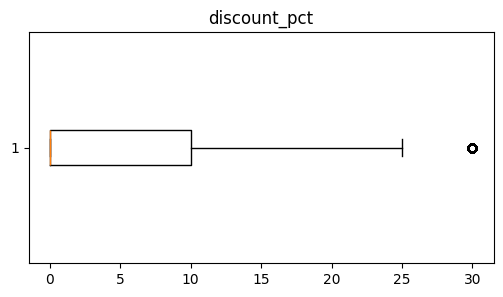

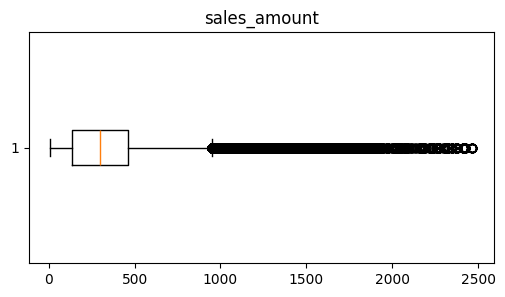

In [38]:


numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

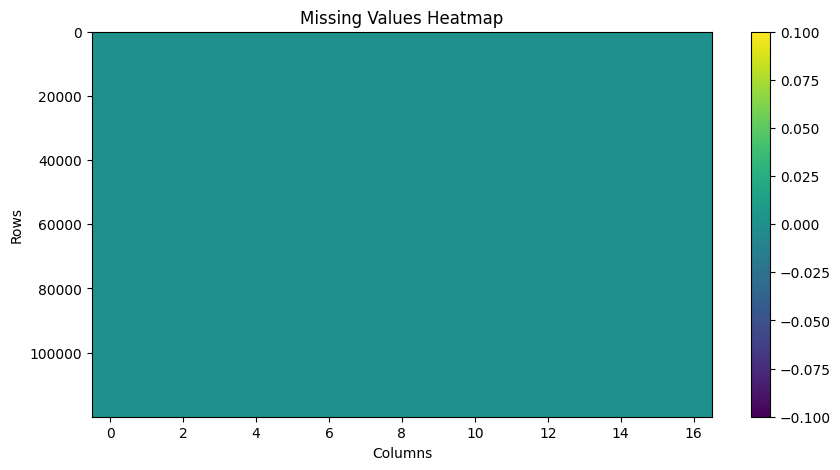

In [39]:
plt.figure(figsize=(10,5))
plt.imshow(df.isnull(), aspect='auto', cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.colorbar()
plt.show()

In [45]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'customer_id',
 'customer_gender',
 'customer_age_group',
 'customer_segment',
 'product_id',
 'product_name',
 'category',
 'brand',
 'quantity',
 'unit_price',
 'discount_pct',
 'sales_amount',
 'payment_method',
 'sales_channel',
 'region']

In [ ]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract date features
df["Year"] = df["transaction_date"].dt.year
df["Month"] = df["transaction_date"].dt.month
df["Day"] = df["transaction_date"].dt.day
df["Weekday"] = df["transaction_date"].dt.day_name()

# Verify
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,Year,Month,Day,Weekday
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,2024,4,24,Wednesday
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,2025,7,12,Saturday
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,2025,6,1,Sunday
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,2025,8,26,Tuesday
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,2024,12,10,Tuesday


In [47]:
category_sales = (
    df.groupby("category")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Beauty         6355718.23
Books          6005237.69
Sports         5863370.76
Electronics    5859686.69
Home           5655562.80
Toys           5557562.19
Groceries      5431536.64
Clothing       4628379.45
Name: sales_amount, dtype: float64

In [48]:
payment_sales = (
    df.groupby("payment_method")["sales_amount"]
      .sum()
)

payment_sales

payment_method
Cash           9134699.83
Credit Card    9127113.77
Debit Card     9028886.06
Gift Card      9032802.90
PayPal         9033551.89
Name: sales_amount, dtype: float64

In [49]:
segment_sales = (
    df.groupby("customer_segment")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

customer_segment
Loyal        11393721.23
New          11331906.60
VIP          11320171.31
Returning    11311255.31
Name: sales_amount, dtype: float64

In [50]:
top_products = (
    df.groupby("product_name")["sales_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

product_name
Bread              2073770.79
Lipstick           2063017.35
Textbook           1737817.74
Smartphone         1631875.41
Water Bottle       1605400.95
Storage Box        1509331.33
Notebook           1478248.61
Toy Car            1423744.56
Building Blocks    1394417.17
Moisturizer        1348009.02
Name: sales_amount, dtype: float64

In [51]:
monthly_sales = (
    df.groupby("Month")["sales_amount"]
      .sum()
)

monthly_sales

Month
1     3905431.21
2     3590625.71
3     3698681.32
4     3725091.08
5     3867973.04
6     3730736.88
7     3914066.95
8     3915285.22
9     3694375.17
10    3783969.21
11    3738674.75
12    3792143.91
Name: sales_amount, dtype: float64

In [52]:
monthly_sales = (
    df.groupby("Month")["sales_amount"]
      .sum()
)

monthly_sales

Month
1     3905431.21
2     3590625.71
3     3698681.32
4     3725091.08
5     3867973.04
6     3730736.88
7     3914066.95
8     3915285.22
9     3694375.17
10    3783969.21
11    3738674.75
12    3792143.91
Name: sales_amount, dtype: float64

In [53]:
print("Total Revenue:", df["sales_amount"].sum())

Total Revenue: 45357054.45


In [54]:
print("Unique Customers:", df["customer_id"].nunique())

Unique Customers: 24784


In [55]:
df.to_csv("data/cleaned_retail_sales.csv", index=False)